In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('/content/sample_data/Company.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
X = df.drop(['Sales'], axis=1)
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Create a Ridge regression model
ridge = Ridge(alpha=1.0)  # You can adjust the alpha parameter
# Fit the model to the training data
ridge.fit(X_train, y_train)

# Predict on the test data
y_pred_ridge = ridge.predict(X_test)

In [6]:
# Create a Lasso regression model
lasso = Lasso(alpha=1.0)  # You can adjust the alpha parameter

# Fit the model to the training data
lasso.fit(X_train, y_train)

# Predict on the test data
y_pred_lasso = lasso.predict(X_test)


[0.05450925 0.100942   0.00433753]
[0.05441052 0.09709914 0.00299795]


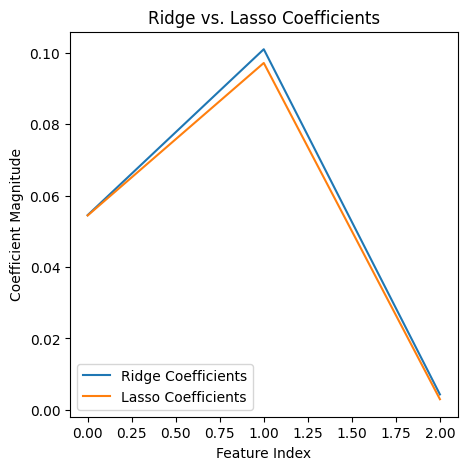

In [7]:
# Get coefficients from Ridge and Lasso models
ridge_coefs = ridge.coef_
lasso_coefs = lasso.coef_
print(ridge_coefs)
print(lasso_coefs)
# Plot the coefficient magnitudes
plt.figure(figsize=(5, 5))
plt.plot(range(len(ridge_coefs)), ridge_coefs, label="Ridge Coefficients")
plt.plot(range(len(lasso_coefs)), lasso_coefs, label="Lasso Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Magnitude")
plt.legend()
plt.title("Ridge vs. Lasso Coefficients")
plt.show()

In [8]:
# Define alpha values for Ridge and Lasso
alpha_ridge = 1.0  # You can change this value
alpha_lasso = 1.0  # You can change this value


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create a Linear Regression model
linear_reg = LinearRegression()

# Fit the model to the training data
linear_reg.fit(X_train, y_train)

# Predict on the test data
y_pred_linear = linear_reg.predict(X_test)

# Get coefficients from Linear Regression model
linear_coefs = linear_reg.coef_
print(f"Linear Regression Coefficients: {linear_coefs}")


Linear Regression Coefficients: [0.05450927 0.10094536 0.00433665]


Now, let's calculate the Mean Squared Error (MSE) for all three models to compare their performance.

In [10]:
# Calculate Mean Squared Error for each model
mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Ridge Regression MSE: {mse_ridge:.2f}")
print(f"Lasso Regression MSE: {mse_lasso:.2f}")


Linear Regression MSE: 2.91
Ridge Regression MSE: 2.91
Lasso Regression MSE: 2.93


Let's update the coefficient plot to include the Linear Regression coefficients for a visual comparison.

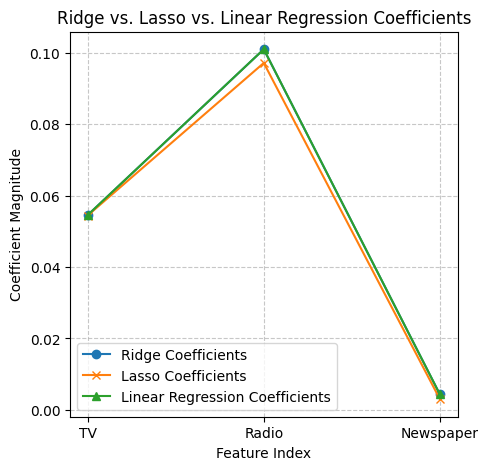

In [11]:
# Plot the coefficient magnitudes for all three models
plt.figure(figsize=(5, 5))
plt.plot(range(len(ridge_coefs)), ridge_coefs, label="Ridge Coefficients", marker='o')
plt.plot(range(len(lasso_coefs)), lasso_coefs, label="Lasso Coefficients", marker='x')
plt.plot(range(len(linear_coefs)), linear_coefs, label="Linear Regression Coefficients", marker='^')
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Magnitude")
plt.xticks(ticks=range(len(X.columns)), labels=X.columns) # Label x-axis with feature names
plt.legend()
plt.title("Ridge vs. Lasso vs. Linear Regression Coefficients")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [12]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load dataset
df = pd.read_csv("/content/sample_data/Company.csv")

# Step 3: Separate features and target
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature scaling (IMPORTANT for Ridge & Lasso)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# ✅ Ridge Regression
# -------------------------------
ridge = Ridge(alpha=1.0)  # alpha = regularization strength
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

# Evaluation
print("Ridge Results")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("Coefficients:", ridge.coef_)

# -------------------------------
# ✅ Lasso Regression
# -------------------------------
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

# Evaluation
print("\nLasso Results")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("Coefficients:", lasso.coef_)

Ridge Results
MSE: 2.915318013511375
R2 Score: 0.9056564972278859
Coefficients: [4.55913661 1.48074139 0.0914114 ]

Lasso Results
MSE: 2.930148052297701
R2 Score: 0.905176577782095
Coefficients: [4.49218143 1.42301597 0.01566227]
